In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

## 2. Chargement du fichier CSV et gestion du préambule
Objectif : Charger le fichier CSV en s'affranchissant des lignes de métadonnées d'extraction initiales et vérifier la structure globale (dimensions, colonnes).

In [3]:
file_path = "../project_data/raw/Entreprises entites stagiaires.csv"

# Chargement en sautant les 21 lignes de préambule textuel et en utilisant l'encodage adapté aux accents français
df_contacts = pd.read_csv(file_path, encoding="latin-1", sep=";", skiprows=21)

# Afficher la taille du DataFrame
print(f"Dimensions du dataset : {df_contacts.shape}")

Dimensions du dataset : (13345, 24)


In [4]:
# Afficher la liste complète des colonnes détectées
df_contacts.columns.tolist()

['Unnamed: 0',
 'Code.Entité',
 'Libellé.Entité',
 "Code.Type d'entité",
 'Assujetti.Entité',
 'Rue (ligne 1).Adresse',
 'Rue (ligne 2).Adresse',
 'Rue (ligne 3).Adresse',
 'Rue (ligne 4).Adresse',
 'Code postal.Ville',
 'Nom.Ville',
 "Code.Type d'adresse",
 'Nombre de stage (sans contrat pro)',
 'Noms des stagiaires',
 'Nombre de contrat pro',
 'Noms des alternants contrats pro',
 'Nombre apprentissage',
 'Noms des apprentis',
 "Code.Type d'événement",
 'Montant global.Taxe versement',
 'Début.Événement',
 'Code.Fonctions',
 'Nom.Individu',
 'Prénom.Individu']

## 3. Analyse des types de données
Objectif : Analyser comment Python interprète les données afin de repérer les anomalies de format ou les variables mal typées.

In [5]:
df_contacts.dtypes

Unnamed: 0                              int64
Code.Entité                               str
Libellé.Entité                            str
Code.Type d'entité                        str
Assujetti.Entité                          str
Rue (ligne 1).Adresse                     str
Rue (ligne 2).Adresse                     str
Rue (ligne 3).Adresse                     str
Rue (ligne 4).Adresse                     str
Code postal.Ville                         str
Nom.Ville                                 str
Code.Type d'adresse                       str
Nombre de stage (sans contrat pro)    float64
Noms des stagiaires                       str
Nombre de contrat pro                 float64
Noms des alternants contrats pro          str
Nombre apprentissage                  float64
Noms des apprentis                        str
Code.Type d'événement                     str
Montant global.Taxe versement             str
Début.Événement                           str
Code.Fonctions                    

## 4. Mesure des valeurs manquantes (Complétude)
Objectif : Mesurer précisément la qualité et la complétude du fichier par colonne afin d'identifier les champs exploitables pour le CRM et ceux nécessitant une qualification.

In [6]:
# Calcul du nombre et du pourcentage de cases vides par colonne
missing_count = df_contacts.isna().sum()
missing_percent = (df_contacts.isna().mean() * 100).round(2)

# Création du DataFrame récapitulatif
missing_summary = pd.DataFrame(
    {"missing_count": missing_count, "missing_percent": missing_percent}
).sort_values("missing_percent", ascending=False)

missing_summary

,missing_count,missing_percent
Rue (ligne 4).Adresse,13269,99.43
Rue (ligne 3).Adresse,12124,90.85
Nombre de stage (sans contrat pro),10731,80.41
Noms des stagiaires,10731,80.41
Nombre apprentissage,10289,77.10
Noms des apprentis,10289,77.10
Nombre de contrat pro,8257,61.87
Noms des alternants contrats pro,8257,61.87
Début.Événement,8160,61.15
Montant global.Taxe versement,8160,61.15


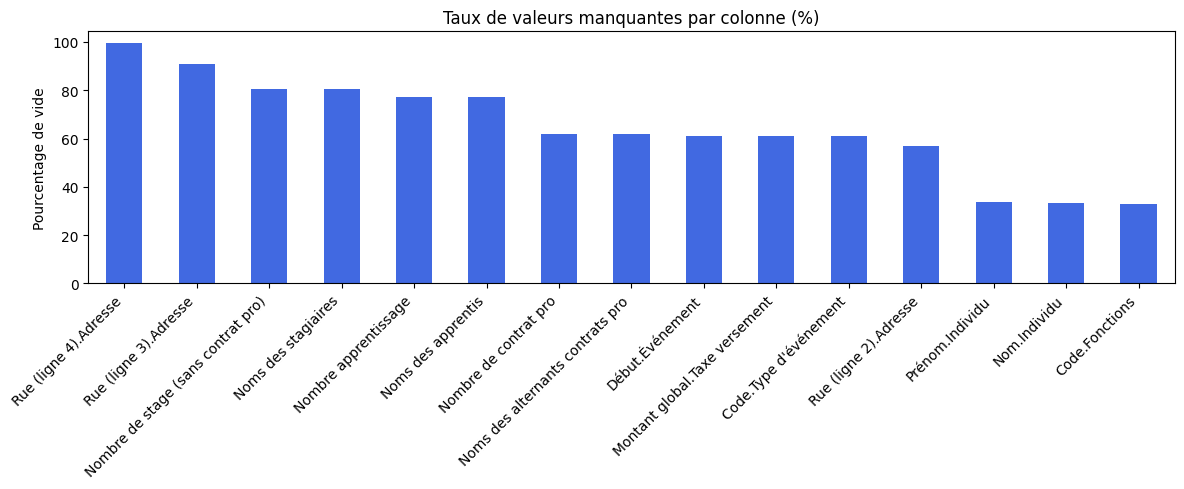

In [7]:
# Visualisation graphique de la complétude (Top 15 des colonnes les plus vides)
plt.figure(figsize=(12, 5))
missing_percent.sort_values(ascending=False).head(15).plot(
    kind="bar", color="royalblue"
)
plt.title("Taux de valeurs manquantes par colonne (%)")
plt.ylabel("Pourcentage de vide")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 5. Analyse de la dimension Métier (Fonctions des contacts)
Objectif : Analyser la colonne Code.Fonctions pour comprendre la typologie des interlocuteurs cibles présents dans notre écosystème.

In [8]:
# Distribution brute des fonctions avec les valeurs manquantes
fonctions_dist = df_contacts["Code.Fonctions"].value_counts(dropna=False)
print(fonctions_dist)

Code.Fonctions
DIRECTION_RH    4952
NaN             4412
DIRECTION       3981
Name: count, dtype: int64


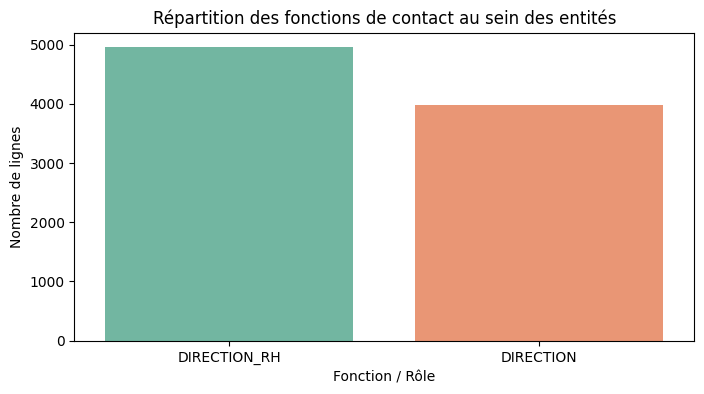

In [9]:
# Visualisation de la répartition des rôles identifiés
plt.figure(figsize=(8, 4))
sns.countplot(
    data=df_contacts,
    x="Code.Fonctions",
    hue="Code.Fonctions",
    palette="Set2",
    legend=False,
)
plt.title("Répartition des fonctions de contact au sein des entités")
plt.xlabel("Fonction / Rôle")
plt.ylabel("Nombre de lignes")
plt.show()

## 6. Analyse des doublons
Objectif : Évaluer le niveau de réplication pure au sein du fichier afin de valider la granularité des données (une ligne représente-t-elle un établissement, un individu ou un événement ?).

In [10]:
# On supprime la colonne d'index technique 'Unnamed: 0' pour analyser les vrais doublons de contenu métier
df_contenu = df_contacts.drop(columns=["Unnamed: 0"], errors="ignore")

total_lignes = len(df_contacts)
doublons_pures = df_contenu.duplicated().sum()
taux_doublons = round((doublons_pures / total_lignes) * 100, 2)

print(f"Volume total de lignes analysées : {total_lignes}")
print(f"Nombre de lignes 100% identiques (doublons de contenu) : {doublons_pures}")
print(f"Taux d'anomalie par duplication : {taux_doublons}%")

Volume total de lignes analysées : 13345
Nombre de lignes 100% identiques (doublons de contenu) : 910
Taux d'anomalie par duplication : 6.82%
